In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from google.genai import types
from IPython.display import Markdown
from dotenv import load_dotenv, find_dotenv

# 1. Securely locate and load the hidden .env file
env_path = find_dotenv()
load_dotenv(env_path, override=True)

# 2. Initialize the client (it will automatically find GEMINI_API_KEY in the background)
client = genai.Client()

print("✅ Setup complete & Gemini client SECURELY initialized!")

✅ Setup complete & Gemini client SECURELY initialized!


In [8]:
# Replace this filename with ANY CSV file you want to analyze in the future!
csv_file = "greek_tourism_data.csv"
df = pd.read_csv(csv_file)

# Automatically identify numeric vs text columns
# Added 'str' to future-proof the code against Pandas 4 updates
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print(f"Successfully loaded '{csv_file}'")
print(f"Found {len(numeric_cols)} numeric columns and {len(categorical_cols)} categorical columns.")

# Preview the first 3 rows
df.head(3)

Successfully loaded 'greek_tourism_data.csv'
Found 4 numeric columns and 3 categorical columns.


,Booking_ID,Region,Guest_Type,Nights_Stayed,Nightly_Rate_EUR,Total_Spend_EUR,Satisfaction_Score
0,BKG-10000,Ionian Islands,Solo,2,213.31,433.31,9.5
1,BKG-10001,Dodecanese,Business,6,160.99,1022.03,7.8
2,BKG-10002,Crete,Couple,12,164.30,2044.13,8.7


In [9]:
shape_info = f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns"
missing_data = df.isnull().sum().to_string()
dtypes_info = df.dtypes.to_string()
stats_summary = df.describe().to_string()
sample_preview = df.head(3).to_string()

print("--- METRICS EXTRACTED SUCCESSFULLY ---")
print(shape_info)

--- METRICS EXTRACTED SUCCESSFULLY ---
Dataset Dimensions: 1000 rows, 7 columns


In [10]:
import json
from google.genai import types

# The Prompt: Force Gemini to act as a Data Scientist and return strict JSON
selection_prompt = f"""
You are an expert Data Scientist. 
Review the following columns from an unknown dataset and choose the most analytically valuable columns to visualize.
DO NOT choose columns that are IDs, postal codes, or unique names. Choose metrics that tell a story.

Dataset Sample (first 3 rows):
{df.head(3).to_string()}

Categorical Columns available: {categorical_cols}
Numeric Columns available: {numeric_cols}

Please select:
1. One categorical column for a bar chart (representing groups or regions).
2. Two numeric columns for a scatter plot (that might have an interesting correlation).
3. One numeric column for a histogram (to view its distribution).

Return ONLY a JSON dictionary with exactly these keys.
{{
  "bar_chart_category": "column_name",
  "scatter_x": "column_name",
  "scatter_y": "column_name",
  "histogram_num": "column_name"
}}
"""

print("Asking Gemini to choose the best columns...")

# We use the config to FORCE the AI to output machine-readable JSON
selection_response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=selection_prompt,
    config=types.GenerateContentConfig(
        response_mime_type="application/json"
    )
)

# Parse the AI's JSON string back into a Python dictionary
ai_selections = json.loads(selection_response.text)

print("✅ Gemini successfully selected the following targets:")
print(json.dumps(ai_selections, indent=2))

Asking Gemini to choose the best columns...
✅ Gemini successfully selected the following targets:
{
  "bar_chart_category": "Region",
  "scatter_x": "Nights_Stayed",
  "scatter_y": "Total_Spend_EUR",
  "histogram_num": "Satisfaction_Score"
}


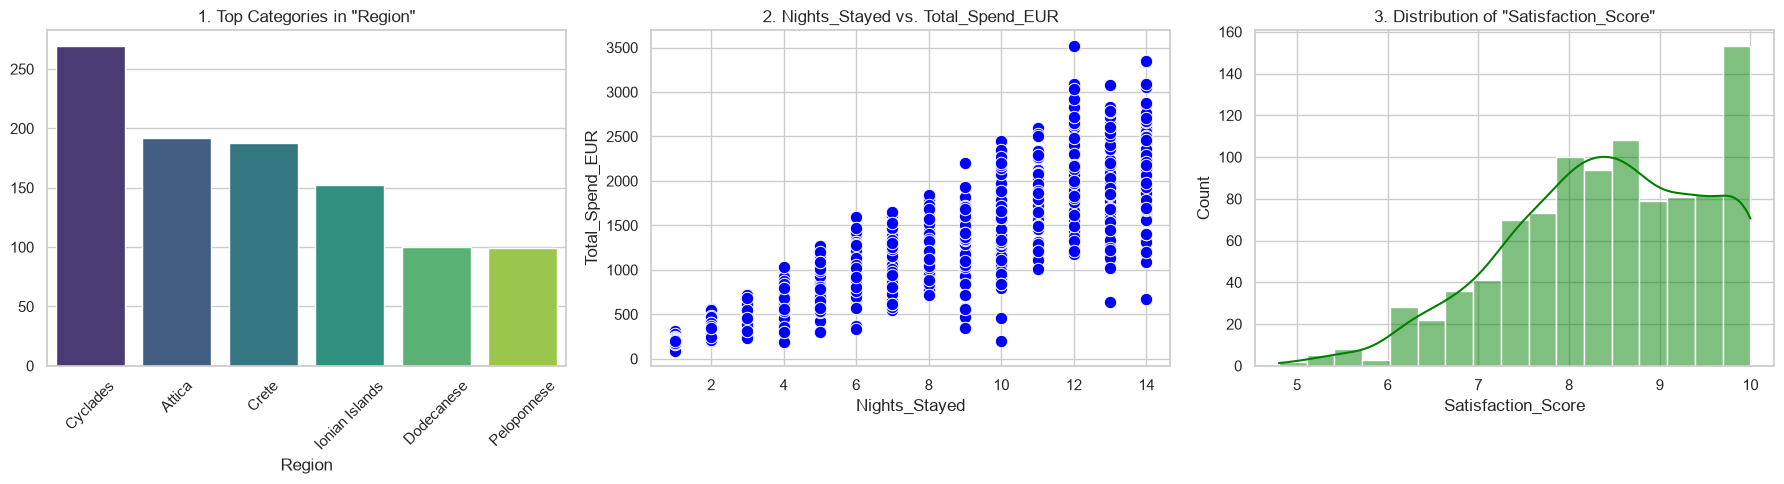

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar Chart
bar_cat = ai_selections.get("bar_chart_category")
if bar_cat and bar_cat in df.columns:
    top_values = df[bar_cat].value_counts().head(10)
    sns.barplot(
        x=top_values.index, 
        y=top_values.values, 
        ax=axes[0], 
        palette="viridis",
        hue=top_values.index,
        legend=False
    )
    axes[0].set_title(f'1. Top Categories in "{bar_cat}"', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)

# 2. Scatter Plot
scatter_x = ai_selections.get("scatter_x")
scatter_y = ai_selections.get("scatter_y")
if scatter_x in df.columns and scatter_y in df.columns:
    sns.scatterplot(data=df, x=scatter_x, y=scatter_y, ax=axes[1], color="blue", s=80)
    axes[1].set_title(f'2. {scatter_x} vs. {scatter_y}', fontsize=12)

# 3. Histogram
hist_num = ai_selections.get("histogram_num")
if hist_num and hist_num in df.columns:
    sns.histplot(data=df, x=hist_num, kde=True, ax=axes[2], color="green")
    axes[2].set_title(f'3. Distribution of "{hist_num}"', fontsize=12)

plt.tight_layout()
plt.savefig("eda_visualizations.png")
plt.show()

In [12]:
from IPython.display import Markdown
from google.genai import types

# 1. Read the saved chart image as raw bytes
with open("eda_visualizations.png", "rb") as f:
    image_bytes = f.read()

image_part = types.Part.from_bytes(
    data=image_bytes,
    mime_type="image/png"
)

# 2. Combined Prompt: Fuses numerical stats + image analysis into concise bullets
combined_prompt = f"""
You are a Senior Data Analyst presenting to an executive board. 
Synthesize BOTH the numerical dataset metrics and the attached visualization dashboard into a single, high-impact Executive Briefing.

--- DATASET NUMERICAL METRICS ---
Scope: {shape_info}

First 3 Sample Rows:
{sample_preview}

Missing Values:
{missing_data}

Numerical Statistics Summary:
{stats_summary}
--------------------------------

INSTRUCTIONS:
- Be EXTREMELY concise. Use ONLY bullet points under the headings below.
- Focus ONLY on the most critical, high-level business takeaways.
- Synthesize numbers and chart observations together.

Generate the report in this exact Markdown structure:

## 📊 Executive Summary & Key Insights

### 1. Dataset Scope & Data Integrity
* [1-2 concise bullets summarizing domain/topic, scope, and any missing data gaps]

### 2. Key Statistical & Visual Findings
* [3-4 concise bullets combining numerical stats and visual trends from the bar chart, scatter plot, and histogram]

### 3. Strategic Leadership Recommendations
* [2-3 concise bulleted action items or strategic questions for executive leadership]
"""

print("Sending stats AND charts to Gemini for combined briefing...")

# 3. Multimodal Call (Text prompt + PNG image)
final_response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=[combined_prompt, image_part]
)

# 4. Save combined report to file
with open("eda_report.md", "w", encoding="utf-8") as f:
    f.write(final_response.text)

# 5. Render directly in notebook
Markdown(final_response.text)

Sending stats AND charts to Gemini for combined briefing...


## 📊 Executive Summary & Key Insights

### 1. Dataset Scope & Data Integrity
* **Scope & Reach**: Evaluated 1,000 guest booking records across 6 Greek regions, tracking duration of stay, nightly rates, overall spend, and guest satisfaction.
* **Data Integrity**: Clean dataset with 100% completeness across primary transactional fields and minimal missing data (15 missing values / 1.5%) restricted solely to `Satisfaction_Score`.

### 2. Key Statistical & Visual Findings
* **Regional Market Dominance**: Cyclades is the primary demand driver with over 260 bookings (~27%), significantly outpacing secondary markets like Attica and Crete (~18-19% each), while Dodecanese and Peloponnese capture the lowest market share (~10% each).
* **Length of Stay Drives Total Spend**: Total revenue averages €1,169.92 per stay (mean nightly rate of €150.65 across an average 7.39 nights), demonstrating a strong linear positive relationship with nights stayed up to maximum spends of €3,520.87 for 12–14 night durations.
* **Highly Positive Satisfaction Baseline**: Guest feedback is strongly left-skewed toward high sentiment, averaging an 8.42/10 satisfaction score, anchored by a prominent peak of maximum 10.0 ratings (~150+ guests) and a minor low-end tail extending down to 4.8.

### 3. Strategic Leadership Recommendations
* **Incentivize Extended Stays**: Structure tiered promotional packages and loyalty perks targeting 7+ night stays to capture higher total yield, as duration is the direct driver of high-value spend (exceeding €2,500–€3,500).
* **Targeted Regional Growth Strategies**: Reallocate marketing expenditure to stimulate low-performing destinations (Dodecanese, Peloponnese) while expanding operational capacity in high-demand hubs like Cyclades.
* **Target Low-Satisfaction Drivers**: Conduct targeted service audits on guests rating below 7.0 (bottom ~10%) to isolate operational pain points and protect brand equity.